# Clustering optimisers with mixed risks and constraints

This example turns the clustering optimiser chapter into a deeper playground for two things
that are easy to miss in the overview:

  - clustering optimisers can mix risk measures and scalarisers across the hierarchy;
  - the hierarchical optimiser can still carry constraints and fees while the cluster logic
    does the diversification work.

We use the same S&P 500 slice as the rest of the examples, then compare a plain HRP solve,
several mixed-risk HERC variants, and a constrained HERC solve.

> **When to reach for this**
>
> Reach for mixed-risk clustering optimisers when no single risk measure captures what you
> care about and you still want the hierarchy to do the diversification — for example
> combining a tail measure with variance, or treating intra-cluster and inter-cluster risk
> differently. The clustering structure keeps the allocation robust while the scalariser
> controls how the mixed risk terms combine.

In [1]:
using PortfolioOptimisers, PrettyTables

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Data and clustering

We compute the prior and cluster hierarchy once, then reuse them across all the examples.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)
clr = clusterise(ClustersEstimator(; alg = DBHT()), pr.X)

# Shared solver and hierarchical optimiser.
slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
opt = HierarchicalOptimiser(; pe = pr, cle = clr, slv = slv)

HierarchicalOptimiser
      pe ┼ LowOrderPrior
         │         X ┼ 252×20 Matrix{Float64}
         │        mu ┼ 20-element Vector{Float64}
         │     sigma ┼ 20×20 Matrix{Float64}
         │      chol ┼ nothing
         │         w ┼ nothing
         │       ens ┼ nothing
         │       kld ┼ nothing
         │        ow ┼ nothing
         │        rr ┼ nothing
         │      f_mu ┼ nothing
         │   f_sigma ┼ nothing
         │       f_w ┴ nothing
     cle ┼ Clusters
         │   res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0], [5, 20, 17, 3, 9, 6, 2, 1, 13, 7, 4, 19, 14, 10, 16, 18, 11, 8, 12, 15], :DBHT)
         │     S ┼ 20×20 Matrix{Float64}
         │     D ┼ 20×20 Matrix{Float64}
         │     P ┼ nothing
         │     k ┴ Int64: 4
   

## 2. HRP with mixed risk measures

`HierarchicalRiskParity` accepts either a single risk measure or a vector of them.
When we pass a vector, the scalariser chooses how to combine the inner risk terms.

Here we mix tail risk and variance, then sweep a few scalarisers to show that the hierarchy
really is responding to the combination rule rather than to a single hidden default.

In [3]:
r_mix = [ConditionalValueatRisk(),
         Variance(; settings = RiskMeasureSettings(; scale = 2e2))]
hrp_sum = optimise(HierarchicalRiskParity(; r = r_mix, opt = opt, sca = SumScalariser()))
hrp_max = optimise(HierarchicalRiskParity(; r = r_mix, opt = opt, sca = MaxScalariser()))
hrp_min = optimise(HierarchicalRiskParity(; r = r_mix, opt = opt, sca = MinScalariser()))
hrp_lse = optimise(HierarchicalRiskParity(; r = r_mix, opt = opt,
                                          sca = LogSumExpScalariser(; gamma = 1e2)))

pretty_table(DataFrame(; :assets => rd.nx, :Sum => hrp_sum.w, :Max => hrp_max.w,
                       :Min => hrp_min.w, :LogSumExp => hrp_lse.w); formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬───────────┐
│ assets │      Sum │      Max │      Min │ LogSumExp │
│ String │  Float64 │  Float64 │  Float64 │   Float64 │
├────────┼──────────┼──────────┼──────────┼───────────┤
│   AAPL │  3.866 % │   3.26 % │  4.801 % │   3.937 % │
│    AMD │  1.669 % │  1.263 % │  2.678 % │    1.53 % │
│    BAC │  3.785 % │  3.356 % │  4.017 % │   4.005 % │
│    BBY │  3.373 % │  2.871 % │  4.403 % │     3.0 % │
│    CVX │  4.403 % │  3.937 % │  4.891 % │     4.7 % │
│     GE │  4.208 % │  3.879 % │  4.133 % │   4.691 % │
│     HD │  2.751 % │  2.605 % │   2.72 % │   3.118 % │
│    JNJ │ 11.741 % │ 13.136 % │ 10.025 % │   10.95 % │
│    JPM │  4.293 % │  3.965 % │  4.208 % │   4.713 % │
│     KO │  5.384 % │  6.299 % │  4.426 % │   5.189 % │
│    LLY │  6.556 % │  5.995 % │  7.372 % │   6.223 % │
│    MRK │  6.076 % │  6.583 % │  5.297 % │   5.813 % │
│   MSFT │  2.345 % │   2.06 % │  2.675 % │   2.477 % │
│    PEP │  9.848 % │  11.24 % │  8.327 % │   9.

## 3. HERC with mixed inner and outer risks

`HierarchicalEqualRiskContribution` lets the inner and outer levels use different
risk measures and scalarisers. That makes it the cleanest place to show the "mixed risk"
idea: the hierarchy can treat intra-cluster and inter-cluster risk differently.

We pair the same mixed risk vector at both levels, then vary the scalariser to show the
contrast between additive, max, min, and log-sum-exp aggregation.

In [4]:
herc_sum = optimise(HierarchicalEqualRiskContribution(; opt = opt, ri = r_mix, ro = r_mix,
                                                      scai = SumScalariser(),
                                                      scao = SumScalariser()))
herc_max = optimise(HierarchicalEqualRiskContribution(; opt = opt, ri = r_mix, ro = r_mix,
                                                      scai = MaxScalariser(),
                                                      scao = MaxScalariser()))
herc_min = optimise(HierarchicalEqualRiskContribution(; opt = opt, ri = r_mix, ro = r_mix,
                                                      scai = MinScalariser(),
                                                      scao = MinScalariser()))
herc_lse = optimise(HierarchicalEqualRiskContribution(; opt = opt, ri = r_mix, ro = r_mix,
                                                      scai = LogSumExpScalariser(;
                                                                                 gamma = 1e2),
                                                      scao = LogSumExpScalariser(;
                                                                                 gamma = 1e2)))

pretty_table(DataFrame(; :assets => rd.nx, :Sum => herc_sum.w, :Max => herc_max.w,
                       :Min => herc_min.w, :LogSumExp => herc_lse.w); formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬───────────┐
│ assets │      Sum │      Max │      Min │ LogSumExp │
│ String │  Float64 │  Float64 │  Float64 │   Float64 │
├────────┼──────────┼──────────┼──────────┼───────────┤
│   AAPL │  2.124 % │  1.857 % │  2.628 % │    2.31 % │
│    AMD │  0.723 % │   0.63 % │  1.445 % │    1.27 % │
│    BAC │  2.552 % │  2.232 % │  2.998 % │   2.635 % │
│    BBY │   1.31 % │  1.144 % │  1.969 % │   1.731 % │
│    CVX │  5.519 % │  4.547 % │  6.078 % │   4.609 % │
│     GE │   2.21 % │  1.934 % │   2.23 % │    1.96 % │
│     HD │  2.739 % │  2.398 % │  2.629 % │   2.311 % │
│    JNJ │ 10.319 % │ 10.791 % │  7.863 % │   8.336 % │
│    JPM │  3.013 % │  2.636 % │  3.141 % │   2.761 % │
│     KO │ 12.774 % │ 13.746 % │ 10.942 % │   12.41 % │
│    LLY │  4.226 % │  4.407 % │  5.503 % │   5.834 % │
│    MRK │  7.883 % │   8.24 % │  6.658 % │   7.058 % │
│   MSFT │  2.168 % │  1.896 % │  2.586 % │   2.273 % │
│    PEP │ 13.062 % │ 14.058 % │ 10.897 % │  12.

The scalariser choice can dominate the solution when one risk measure is consistently larger
than the other. That is why the max and min solutions can collapse toward the portfolio that
is effectively minimising the dominating term.

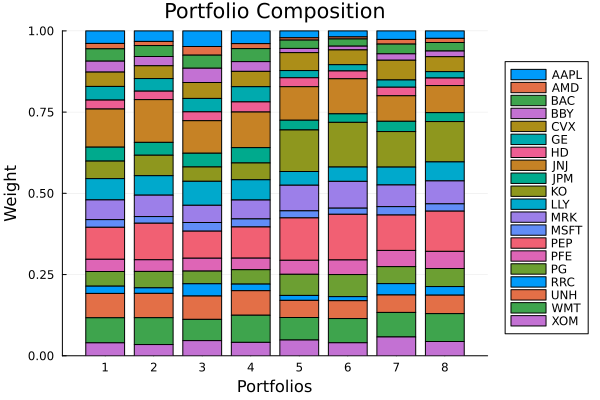

In [5]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition([hrp_sum, hrp_max, hrp_min, hrp_lse, herc_sum, herc_max,
                              herc_min, herc_lse], rd)

## 4. Constrained HERC

The hierarchical optimiser itself can still carry weight bounds and fees. This version keeps
the same mixed risk structure, but asks the optimiser to stay inside a bounded, fee-aware
universe. We set a 10% cap (`ub = 0.1`) deliberately tight enough to bind: the unconstrained
HERC already concentrates around 13% in the largest names, so the cap pulls them down — watch
the largest holdings in the comparison below.

In [6]:
opt_constrained = HierarchicalOptimiser(; pe = pr, cle = clr, slv = slv,
                                        wb = WeightBounds(; lb = 0.0, ub = 0.1),
                                        fees = Fees(; l = 0.001))
herc_constrained = optimise(HierarchicalEqualRiskContribution(; opt = opt_constrained,
                                                              ri = r_mix, ro = r_mix,
                                                              scai = SumScalariser(),
                                                              scao = SumScalariser()))

pretty_table(DataFrame(; :assets => rd.nx, :Unconstrained => herc_sum.w,
                       :Constrained => herc_constrained.w); formatters = [resfmt])

┌────────┬───────────────┬─────────────┐
│ assets │ Unconstrained │ Constrained │
│ String │       Float64 │     Float64 │
├────────┼───────────────┼─────────────┤
│   AAPL │       2.124 % │     2.342 % │
│    AMD │       0.723 % │     0.797 % │
│    BAC │       2.552 % │     2.814 % │
│    BBY │        1.31 % │     1.444 % │
│    CVX │       5.519 % │     6.105 % │
│     GE │        2.21 % │     2.437 % │
│     HD │       2.739 % │     3.021 % │
│    JNJ │      10.319 % │      10.0 % │
│    JPM │       3.013 % │     3.322 % │
│     KO │      12.774 % │      10.0 % │
│    LLY │       4.226 % │     4.604 % │
│    MRK │       7.883 % │     8.586 % │
│   MSFT │       2.168 % │     2.391 % │
│    PEP │      13.062 % │      10.0 % │
│    PFE │       4.304 % │     4.689 % │
│      ⋮ │             ⋮ │           ⋮ │
└────────┴───────────────┴─────────────┘
                          5 rows omitted


The risk-contribution view shows how the hierarchy spreads risk rather than capital.
Populate the covariance via `factory` before calling `plot_risk_contribution`.

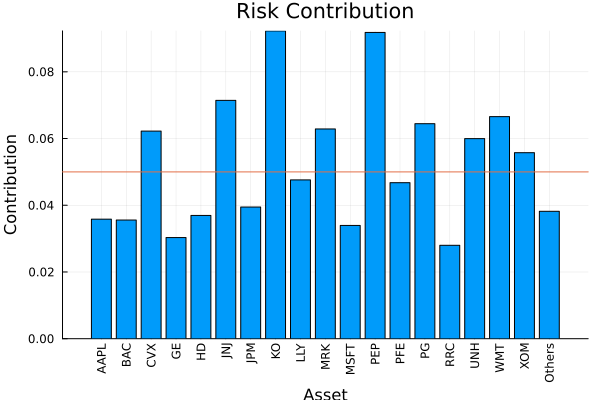

In [7]:
rv = factory(Variance(), pr)
plot_risk_contribution(rv, herc_constrained, rd)

## Summary

Clustering optimisers give you a hierarchical lever on diversification.

  - `HierarchicalRiskParity` responds to the scalariser when you mix risk measures.
  - `HierarchicalEqualRiskContribution` lets inner and outer levels use different
    risk terms and different scalarisers.
  - `HierarchicalOptimiser` can still carry practical constraints like weight bounds
    and fees while the hierarchy does the allocation.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*